In [1]:
import pandas as pd
import numpy as np

In [2]:
netflix = pd.read_csv(r"C:\Users\Enock Kojo Acquah\Documents\Netflix-Analysis\NetflixData_Kaggle\netflix_titles.csv")

In [3]:
netflix.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
netflix.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
netflix.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
netflix.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


# Filled missing director/cast/country with 'Unknown'

In [8]:
# Fill in the missing values in the 'director' column with 'Unknown'
netflix['director'] = netflix['director'].fillna('Unknown')


In [9]:
# Fill in the missing values in the 'cast' column with 'Unknown'
netflix['cast'] = netflix['cast'].fillna('Unknown')

In [10]:
# Fill in the missing values in the 'cast' column with 'Unknown'
netflix['cast'] = netflix['cast'].fillna('Unknown')

# Dropped rows with missing country/date_added/rating/duration (<0.15% of data)

In [11]:
# Drop rows for the near zero missing columns
netflix = netflix.dropna(subset=['country', 'date_added', 'rating', 'duration'])

In [12]:
netflix.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

# Visualizations

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

## Chart 1: Movies vs TV Shows

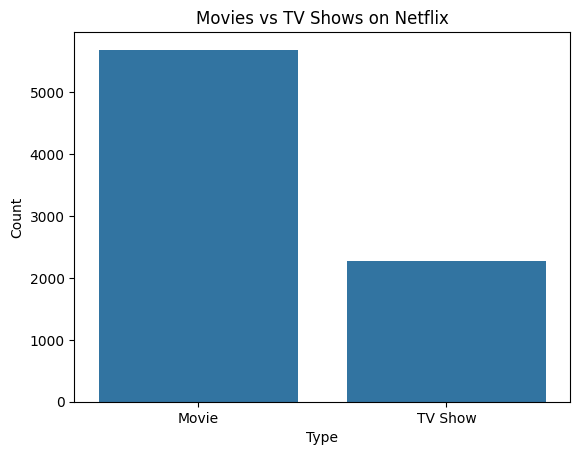

In [15]:
sns.countplot(data=netflix, x='type')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

## Insight: Content Type
### Movies dominate the Netflix catalog, making up roughly 70% of all titles (6,131 of 8,807), with TV Shows accounting for the remaining ~30%. This suggests Netflix's content strategy has historically prioritized film acquisition/production over series, though this ratio may shift as streaming competition around original series has intensified.

## Chart 2: Top 10 countries by title count

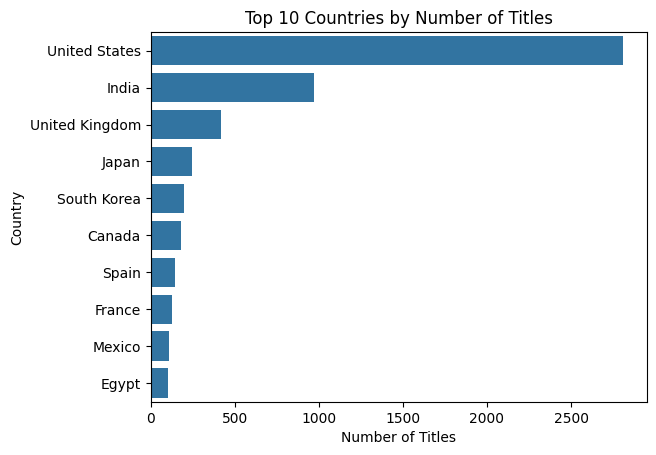

In [16]:
top_countries = netflix['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

## Insight: Leading Countries
### The United States is the single largest source of content, with 2,818 titles — more than triple the next closest country. This reflects Netflix's origins as a US-based platform, though the presence of other countries in the top 10 hints at its international expansion strategy.

## Chart 3: Titles added per year

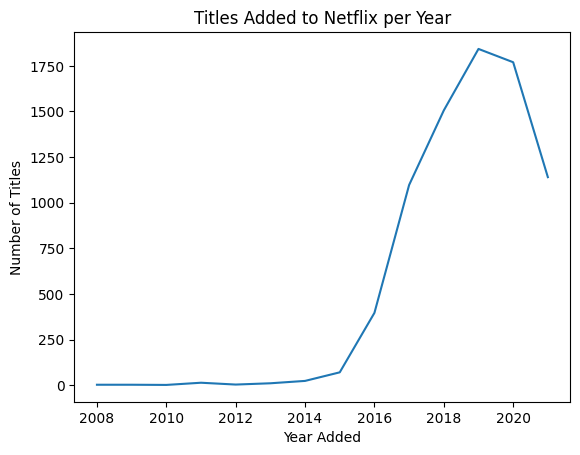

In [21]:
netflix['date_added'] = pd.to_datetime(netflix['date_added'], errors='coerce')
netflix['year_added'] = netflix['date_added'].dt.year

titles_per_year = netflix['year_added'].value_counts().sort_index()

sns.lineplot(x=titles_per_year.index, y=titles_per_year.values)
plt.title('Titles Added to Netflix per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

## Insight: Catalog Growth Over Time
### Netflix's content additions grew sharply between 2016 and 2019, peaking at roughly 1,850 titles added in 2019 alone. Growth declined in 2020 and fell further in 2021 — plausibly linked to COVID-19 disruptions to film and TV production worldwide, though the 2021 figure may also reflect an incomplete year of data collection.

In [22]:
# Chart 4: Top 10 genres

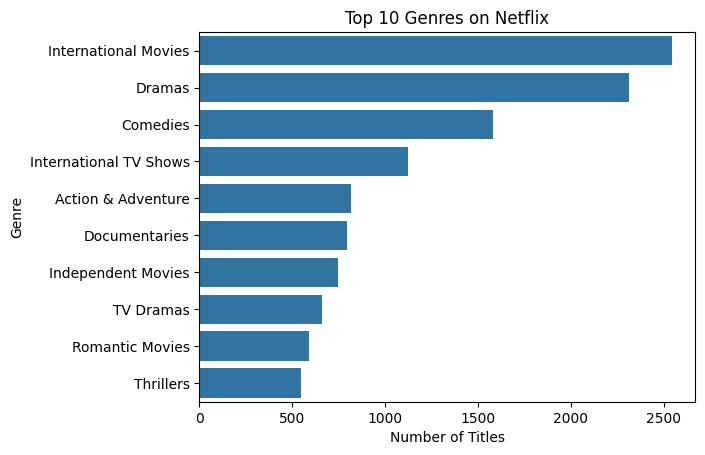

In [23]:
all_genres = netflix['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

# Insight: Genre Distribution
## International Movies is the most common genre (2,500+ titles), followed by Dramas and Comedies. The catalog shows a diverse spread across genres rather than concentration in one or two categories, though international content is clearly a strategic focus.




In [24]:
netflix.groupby('type')['rating'].value_counts()

type     rating  
Movie    TV-MA       1924
         TV-14       1307
         R            787
         TV-PG        504
         PG-13        482
         PG           281
         TV-G         109
         TV-Y          84
         TV-Y7         83
         NR            75
         G             41
         TV-Y7-FV       4
         NC-17          3
         UR             3
TV Show  TV-MA       1005
         TV-14        620
         TV-PG        267
         TV-Y7        152
         TV-Y         143
         TV-G          81
         NR             4
         R              1
         TV-Y7-FV       1
Name: count, dtype: int64

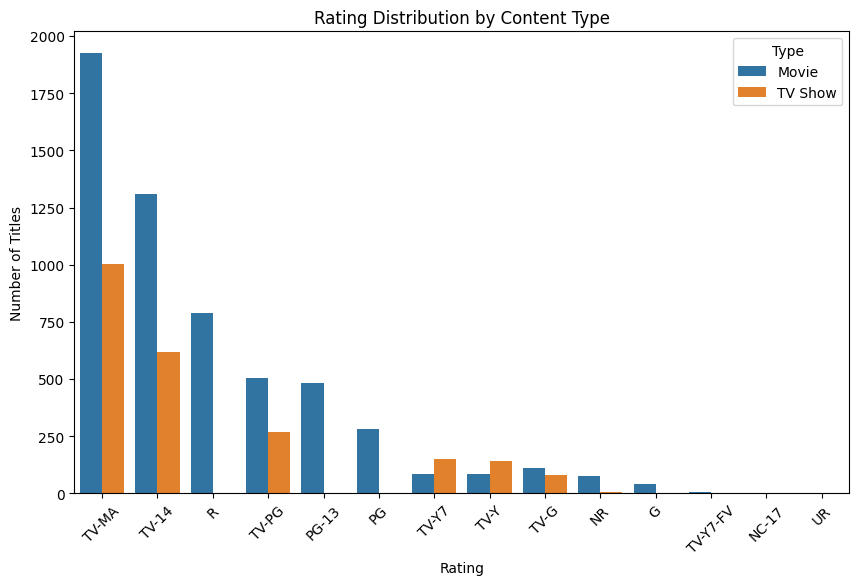

In [25]:
plt.figure(figsize=(10,6))
sns.countplot(data=netflix, x='rating', hue='type', order=netflix['rating'].value_counts().index)
plt.title('Rating Distribution by Content Type')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.show()

## Insight: Rating Distribution by Content Type
### TV-MA and TV-14 are the leading ratings across both Movies and TV Shows, reinforcing that Netflix's catalog skews toward mature and teen audiences overall. However, Movies show a noticeably wider ratings spread — including R, PG-13, PG, and G — categories that are rare or absent for TV Shows. This reflects that Movies and TV Shows draw from different rating systems (MPAA for film vs. TV Parental Guidelines for series), and suggests Netflix's movie catalog serves a broader range of audience maturity levels than its TV show catalog.